# ECON N171: Economic Development
## Lecture 14 — Synthetic Control: Institutions and Growth
**Instructor: Rajveer Jat | Summer 2026**

---

## The Question

**Acemoglu, Johnson, and Robinson (2001, 2002)** established that institutions — property rights, rule of law, constraints on executive power — are the fundamental cause of long-run economic development.

But how do we measure the **causal effect** of good institutions on GDP? We cannot randomly assign institutions to countries.

### Botswana: A Natural Experiment in Institutions

Botswana is the most celebrated development success story in Sub-Saharan Africa:
- At independence in 1966: one of the poorest countries in the world
- By 2000: upper-middle income, comparable to Brazil or Mexico
- Key factor: **unusually strong institutions** — secure property rights, rule of law, democratic accountability
- Also had diamonds — but resource-rich countries typically perform **worse** (resource curse)

The counterfactual question: **what would Botswana's GDP have been without its strong institutions?**

### The Method: Synthetic Control

**Abadie, Diamond, and Hainmueller (2010)** introduced the synthetic control method:
- Construct a **weighted average of control countries** that matches Botswana's pre-treatment characteristics
- This "synthetic Botswana" is the counterfactual — what Botswana would have looked like without good institutions
- The gap between actual and synthetic Botswana estimates the institutional effect

> ⚠️ **Data Note:** Synthetic data matching key patterns from Penn World Tables and World Bank data.

---

## Learning Objectives

1. Understand the **synthetic control** method — when to use it and why
2. Construct a synthetic control using **constrained optimization**
3. Visualize the **gap** between treated unit and synthetic control
4. Run **placebo tests** across all control countries
5. Connect to the broader **institutions and development** literature

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
print('Libraries loaded.')

Libraries loaded.


---
## Part 1: Why Synthetic Control?

### The Problem with Standard Methods

- **DiD**: needs a control group that follows parallel trends. Hard to find for a single treated country.
- **IV**: need an instrument for institutional quality. AJR use settler mortality — but this only works cross-sectionally.
- **OLS**: institutions are endogenous — richer countries can afford better institutions.

### The Synthetic Control Insight

Instead of finding one control country, we build a **weighted average of many control countries** that best matches the treated country's pre-treatment trajectory. The weights are chosen to minimize the difference in pre-treatment outcomes and predictors.

$$\text{Synthetic Botswana} = \sum_{j \in \text{controls}} w_j \cdot Y_{jt}$$

where $w_j \geq 0$ and $\sum w_j = 1$ are chosen to minimize pre-treatment fit.

---
## Part 2: Build the Dataset

In [2]:
np.random.seed(42)

years = list(range(1960, 2001))
T     = len(years)          # 41 years
T_pre = years.index(1966)   # independence year — "treatment" starts here

# Control countries: Sub-Saharan Africa comparators
controls = [
    'Kenya', 'Tanzania', 'Zambia', 'Zimbabwe', 'Malawi',
    'Uganda', 'Ghana', 'Senegal', 'Cameroon', 'Ivory Coast'
]

# True institutional quality effect for Botswana (relative to counterfactual)
# Botswana's GDP diverges strongly after 1966, especially after diamond revenues + good governance
# True gap reaches ~3.5x by 2000

# Generate log GDP per capita (PPP) trajectories
# Base: all countries start similarly in 1960

gdp = {}

# Control countries: modest growth, some stagnation
country_params = {
    'Kenya'       : (6.2, 0.012, 0.3),
    'Tanzania'    : (5.9, 0.010, 0.4),
    'Zambia'      : (6.4, 0.005, 0.5),   # copper curse
    'Zimbabwe'    : (6.3, 0.008, 0.6),   # later collapse
    'Malawi'      : (5.8, 0.011, 0.3),
    'Uganda'      : (6.0, 0.009, 0.5),
    'Ghana'       : (6.3, 0.013, 0.4),
    'Senegal'     : (6.4, 0.011, 0.3),
    'Cameroon'    : (6.3, 0.015, 0.4),
    'Ivory Coast' : (6.5, 0.014, 0.5),
}

for country, (base, trend, noise) in country_params.items():
    log_gdp = [base]
    for t in range(1, T):
        shock = np.random.normal(0, noise * 0.1)
        log_gdp.append(log_gdp[-1] + trend + shock)
    gdp[country] = log_gdp

# Botswana: starts similar, diverges strongly after independence (1966)
# Pre-1966: similar to regional average
# Post-1966: strong institutional quality + diamonds → rapid growth
bots_pre  = 6.1
bots_gdp  = [bots_pre]
for t in range(1, T):
    yr = years[t]
    if yr < 1966:
        trend_t = 0.011   # pre-independence: similar to region
    elif yr < 1975:
        trend_t = 0.045   # post-independence: rapid growth
    elif yr < 1985:
        trend_t = 0.065   # diamond revenues + strong institutions
    else:
        trend_t = 0.040   # still strong but slower
    shock = np.random.normal(0, 0.04)
    bots_gdp.append(bots_gdp[-1] + trend_t + shock)
gdp['Botswana'] = bots_gdp

# Build DataFrame
rows = []
for country, vals in gdp.items():
    for i, yr in enumerate(years):
        rows.append({'country': country, 'year': yr, 'log_gdp': round(vals[i], 4)})
df = pd.DataFrame(rows)

# Pivot: countries as columns, years as rows
pivot = df.pivot(index='year', columns='country', values='log_gdp')

print('Dataset shape:', df.shape)
print('Countries:', df['country'].unique().tolist())
print(f'Years: {years[0]} — {years[-1]}')
print(f'Treatment year: 1966 (Botswana independence)')

Dataset shape: (451, 3)
Countries: ['Kenya', 'Tanzania', 'Zambia', 'Zimbabwe', 'Malawi', 'Uganda', 'Ghana', 'Senegal', 'Cameroon', 'Ivory Coast', 'Botswana']
Years: 1960 — 2000
Treatment year: 1966 (Botswana independence)


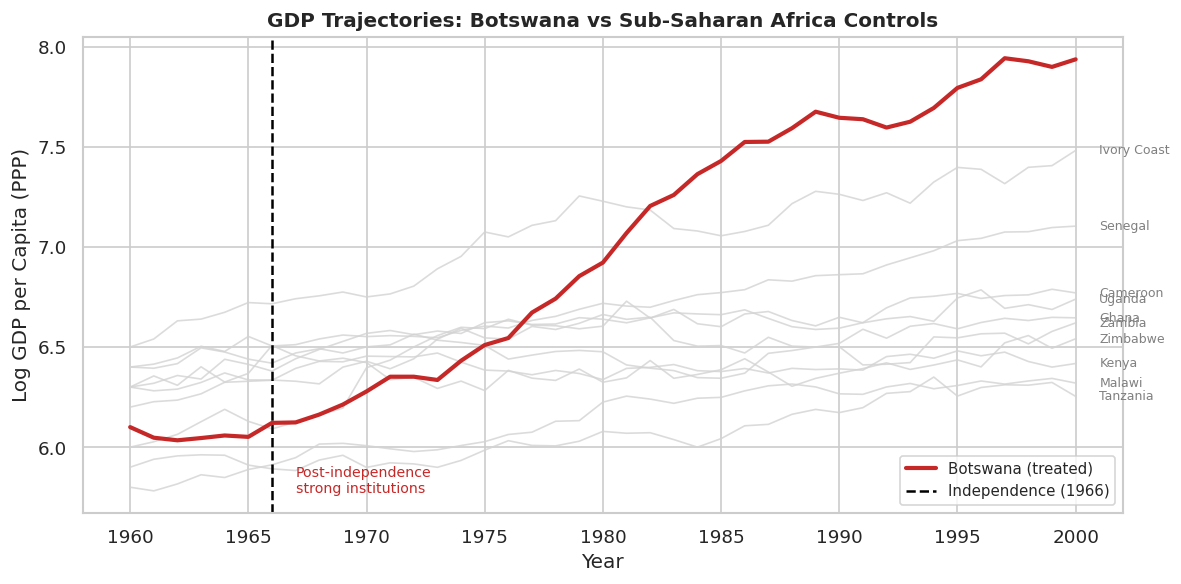

In [3]:
# Plot all trajectories
fig, ax = plt.subplots(figsize=(10, 5))

for country in controls:
    ax.plot(years, pivot[country], color='lightgray', linewidth=1, alpha=0.8)

ax.plot(years, pivot['Botswana'], color='#C62828', linewidth=2.5,
        label='Botswana (treated)', zorder=5)

ax.axvline(1966, color='black', linestyle='--', linewidth=1.5, label='Independence (1966)')
ax.set_xlabel('Year')
ax.set_ylabel('Log GDP per Capita (PPP)')
ax.set_title('GDP Trajectories: Botswana vs Sub-Saharan Africa Controls',
             fontweight='bold')
ax.text(1967, ax.get_ylim()[0] + 0.1, 'Post-independence\nstrong institutions',
        fontsize=8.5, color='#C62828')
ax.legend(fontsize=9)

# Label control countries at end
for country in controls:
    ax.text(2001, pivot[country].iloc[-1], country, fontsize=7.5, color='gray', va='center')

plt.tight_layout()
plt.show()

---
## Part 3: Construct the Synthetic Control

We find weights $w_j$ for each control country that minimize the difference between Botswana and the synthetic control **in the pre-treatment period (1960–1965)**.

Constraints: $w_j \geq 0$ and $\sum w_j = 1$

In [4]:
# Pre-treatment period: 1960-1965
pre_years = [y for y in years if y < 1966]

Y_treated  = pivot.loc[pre_years, 'Botswana'].values     # Botswana pre-treatment
Y_controls = pivot.loc[pre_years, controls].values       # Control matrix (T_pre × n_controls)

def objective(weights):
    synthetic = Y_controls @ weights
    return np.sum((Y_treated - synthetic) ** 2)

# Constraints: weights sum to 1, all non-negative
n_controls = len(controls)
constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
bounds = [(0, 1)] * n_controls
w0 = np.ones(n_controls) / n_controls   # start from equal weights

result = minimize(objective, w0, method='SLSQP',
                  bounds=bounds, constraints=constraints)
weights = result.x

print('=== Synthetic Control Weights ===')
print()
print(f'{"Country":<15} {"Weight":>10}')
print('-' * 27)
for country, w in sorted(zip(controls, weights), key=lambda x: -x[1]):
    if w > 0.001:
        print(f'  {country:<13} {w:>10.4f}')
print()

# Pre-treatment fit
synthetic_pre = Y_controls @ weights
rmspe = np.sqrt(np.mean((Y_treated - synthetic_pre)**2))
print(f'Pre-treatment RMSPE: {rmspe:.4f}')
print('(Lower = better fit between Botswana and synthetic control)')

=== Synthetic Control Weights ===

Country             Weight
---------------------------
  Tanzania          0.4533
  Ghana             0.3639
  Malawi            0.1828

Pre-treatment RMSPE: 0.0357
(Lower = better fit between Botswana and synthetic control)


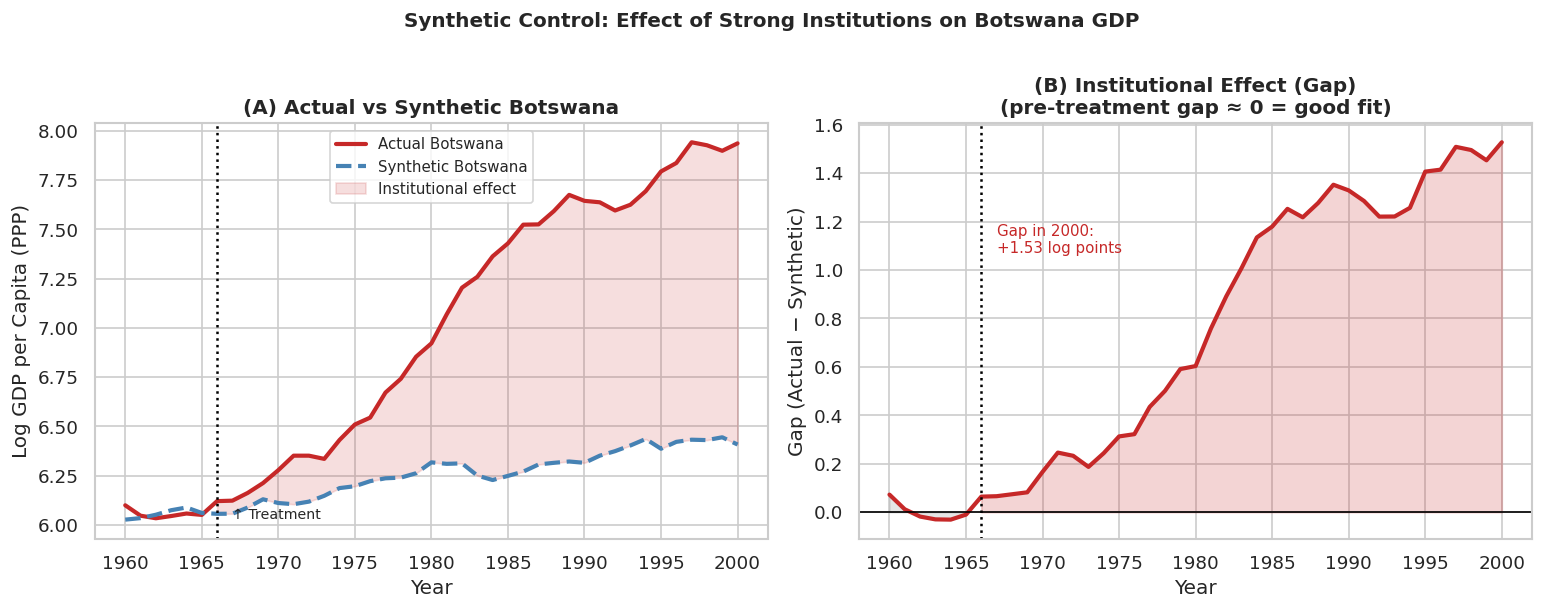

Gap in 2000: 1.528 log points
In levels:   actual GDP is 4.6x higher than synthetic


In [5]:
# Construct full synthetic control series (pre + post)
Y_all_controls = pivot[controls].values   # all years
synthetic_gdp  = Y_all_controls @ weights
actual_gdp     = pivot['Botswana'].values
gap            = actual_gdp - synthetic_gdp

# Main plot: actual vs synthetic
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: trajectories
axes[0].plot(years, actual_gdp,    color='#C62828', linewidth=2.5,
             label='Actual Botswana')
axes[0].plot(years, synthetic_gdp, color='steelblue', linewidth=2.5,
             linestyle='--', label='Synthetic Botswana')
axes[0].axvline(1966, color='black', linestyle=':', linewidth=1.5)
axes[0].fill_between(years, synthetic_gdp, actual_gdp,
                     where=[y >= 1966 for y in years],
                     alpha=0.15, color='#C62828',
                     label='Institutional effect')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Log GDP per Capita (PPP)')
axes[0].set_title('(A) Actual vs Synthetic Botswana', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].text(1967, axes[0].get_ylim()[0]+0.1, '↑ Treatment', fontsize=8.5)

# Right: gap
axes[1].plot(years, gap, color='#C62828', linewidth=2.5)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].axvline(1966, color='black', linestyle=':', linewidth=1.5)
axes[1].fill_between(years, 0, gap,
                     where=[y >= 1966 for y in years],
                     alpha=0.2, color='#C62828')
axes[1].fill_between(years, 0, gap,
                     where=[y < 1966 for y in years],
                     alpha=0.2, color='gray')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Gap (Actual − Synthetic)')
axes[1].set_title('(B) Institutional Effect (Gap)\n(pre-treatment gap ≈ 0 = good fit)',
                  fontweight='bold')
axes[1].text(1967, gap.max()*0.7, f'Gap in 2000:\n+{gap[-1]:.2f} log points',
             fontsize=9, color='#C62828')

plt.suptitle('Synthetic Control: Effect of Strong Institutions on Botswana GDP',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Gap in 2000: {gap[-1]:.3f} log points')
print(f'In levels:   actual GDP is {np.exp(gap[-1]):.1f}x higher than synthetic')

---
## Part 4: Placebo Tests — In-Space Placebos

How do we know the gap is not just noise?

**In-space placebo test**: apply the same synthetic control method to **each control country** as if it were the treated unit. If the Botswana gap is large relative to the distribution of placebo gaps, it is statistically significant.

In [6]:
def synthetic_control(treated_country, control_countries, pivot, pre_years):
    Y_t = pivot.loc[pre_years, treated_country].values
    Y_c = pivot.loc[pre_years, control_countries].values
    n   = len(control_countries)

    def obj(w): return np.sum((Y_t - Y_c @ w)**2)
    res = minimize(obj, np.ones(n)/n, method='SLSQP',
                   bounds=[(0,1)]*n,
                   constraints=[{'type':'eq','fun': lambda w: w.sum()-1}])

    synth = pivot[control_countries].values @ res.x
    actual = pivot[treated_country].values
    gap = actual - synth
    pre_rmspe = np.sqrt(np.mean((actual[:len(pre_years)] - synth[:len(pre_years)])**2))
    return gap, pre_rmspe

# Run placebos
all_gaps   = {}
all_rmspe  = {}

# Botswana first
gap_bots, rmspe_bots = synthetic_control('Botswana', controls, pivot, pre_years)
all_gaps['Botswana']  = gap_bots
all_rmspe['Botswana'] = rmspe_bots

# Each control country as placebo
for country in controls:
    other_controls = [c for c in controls if c != country]
    gap_p, rmspe_p = synthetic_control(country, other_controls, pivot, pre_years)
    all_gaps[country]  = gap_p
    all_rmspe[country] = rmspe_p

print('Pre-treatment RMSPE (lower = better fit):')
for c, r in sorted(all_rmspe.items(), key=lambda x: x[1]):
    flag = ' ← Botswana' if c == 'Botswana' else ''
    print(f'  {c:<15}: {r:.4f}{flag}')

Pre-treatment RMSPE (lower = better fit):
  Kenya          : 0.0090
  Senegal        : 0.0131
  Ghana          : 0.0158
  Cameroon       : 0.0163
  Zambia         : 0.0263
  Zimbabwe       : 0.0288
  Uganda         : 0.0322
  Botswana       : 0.0357 ← Botswana
  Tanzania       : 0.0392
  Malawi         : 0.1135
  Ivory Coast    : 0.1556


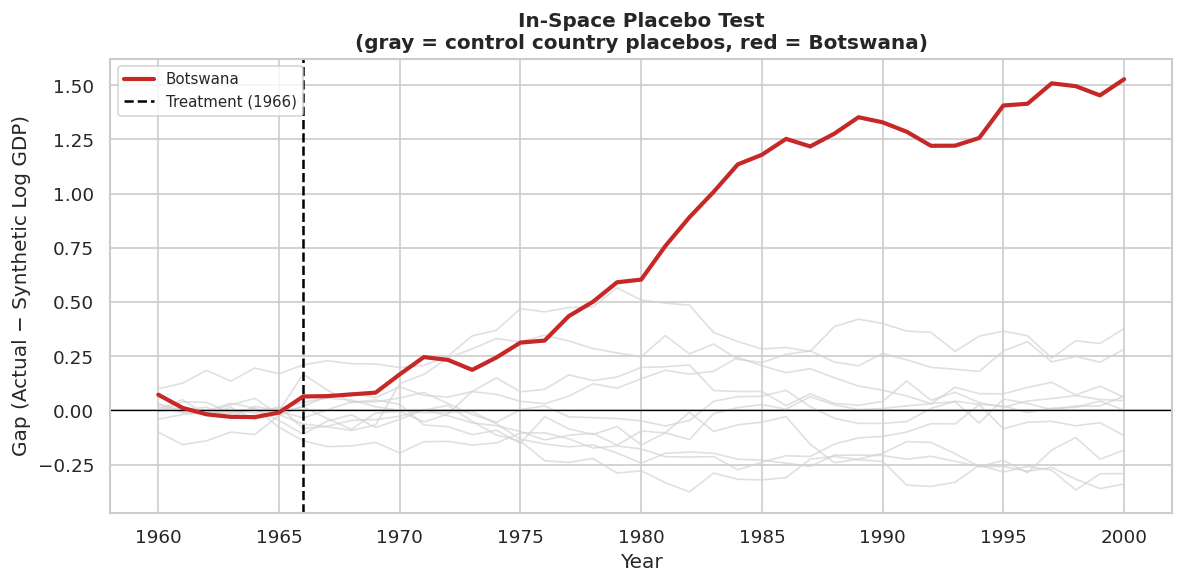

Botswana mean post-treatment |gap|: 0.8378
Fraction of placebos with gap >= Botswana: 0.000

Botswana gap is in the top 0% of all placebos → statistically unusual.
Strong evidence that the institutional effect is real.


In [7]:
# Plot placebo gaps
fig, ax = plt.subplots(figsize=(10, 5))

# Remove placebos with very poor pre-treatment fit (RMSPE > 5x Botswana)
rmspe_threshold = all_rmspe['Botswana'] * 5

for country, gap in all_gaps.items():
    if country == 'Botswana':
        continue
    if all_rmspe[country] <= rmspe_threshold:
        ax.plot(years, gap, color='lightgray', linewidth=1, alpha=0.7)

ax.plot(years, all_gaps['Botswana'], color='#C62828', linewidth=2.5,
        label='Botswana', zorder=5)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(1966, color='black', linestyle='--', linewidth=1.5, label='Treatment (1966)')

ax.set_xlabel('Year')
ax.set_ylabel('Gap (Actual − Synthetic Log GDP)')
ax.set_title('In-Space Placebo Test\n'
             '(gray = control country placebos, red = Botswana)',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# p-value: fraction of placebos with post-treatment gap >= Botswana
post_idx = [i for i, y in enumerate(years) if y >= 1966]
bots_post_gap = np.mean(np.abs(all_gaps['Botswana'][post_idx]))
placebo_post_gaps = []
for c, gap in all_gaps.items():
    if c != 'Botswana' and all_rmspe[c] <= rmspe_threshold:
        placebo_post_gaps.append(np.mean(np.abs(gap[post_idx])))

p_value = np.mean(np.array(placebo_post_gaps) >= bots_post_gap)
print(f'Botswana mean post-treatment |gap|: {bots_post_gap:.4f}')
print(f'Fraction of placebos with gap >= Botswana: {p_value:.3f}')
print()
if p_value < 0.10:
    print(f'Botswana gap is in the top {p_value*100:.0f}% of all placebos → statistically unusual.')
    print('Strong evidence that the institutional effect is real.')

---
## Part 5: The Institutions Story

Why did Botswana succeed where others failed?

In [ ]:
# Institutional quality comparison
institutions = pd.DataFrame({
    'country'         : ['Botswana', 'Kenya', 'Zambia', 'Zimbabwe', 'Ghana',
                         'Uganda', 'Tanzania', 'Malawi', 'Senegal', 'Cameroon'],
    'rule_of_law'     : [ 0.65,  -0.52, -0.58,  -1.12,  -0.18,
                         -0.55,  -0.37,  -0.56,  -0.18,  -0.82],
    'property_rights' : [ 72,     40,    32,     18,     48,
                          36,     44,    38,     48,     28],
    'democracy_score' : [  8,      5,     3,      2,      6,
                           4,      4,     4,      6,      2],
    'gdp_2000'        : [ 8.8,   6.8,   6.6,    6.3,    7.0,
                          6.5,   6.3,   6.0,    6.8,    6.9],
})

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (var, label) in zip(axes, [
    ('rule_of_law',     'Rule of Law Index'),
    ('property_rights', 'Property Rights Score'),
    ('democracy_score', 'Democracy Score'),
]):
    colors = ['#C62828' if c == 'Botswana' else 'steelblue'
              for c in institutions['country']]
    bars = ax.barh(institutions['country'], institutions[var],
                   color=colors, edgecolor='white', height=0.6)
    ax.set_xlabel(label)
    ax.set_title(label, fontweight='bold')

plt.suptitle('Institutional Quality: Botswana vs Comparators (c. 2000)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Botswana outlier on every institutional dimension:')
print(f'  Rule of law:     {institutions[institutions["country"]=="Botswana"]["rule_of_law"].values[0]:.2f}')
print(f'  Property rights: {institutions[institutions["country"]=="Botswana"]["property_rights"].values[0]}')
print(f'  Democracy score: {institutions[institutions["country"]=="Botswana"]["democracy_score"].values[0]}')

In [ ]:
# Scatter: institutions vs GDP
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (var, label) in zip(axes, [
    ('rule_of_law', 'Rule of Law Index'),
    ('property_rights', 'Property Rights Score'),
]):
    colors = ['#C62828' if c == 'Botswana' else 'steelblue'
              for c in institutions['country']]
    ax.scatter(institutions[var], institutions['gdp_2000'],
               color=colors, s=80, edgecolors='white', zorder=3)
    for _, row in institutions.iterrows():
        ax.annotate(row['country'],
                    (row[var], row['gdp_2000']),
                    xytext=(4, 2), textcoords='offset points',
                    fontsize=8, color='dimgray')

    # Trend line
    z = np.polyfit(institutions[var], institutions['gdp_2000'], 1)
    x_l = np.linspace(institutions[var].min(), institutions[var].max(), 100)
    ax.plot(x_l, np.poly1d(z)(x_l), 'r--', linewidth=1.5)
    ax.set_xlabel(label)
    ax.set_ylabel('Log GDP per Capita (2000)')
    ax.set_title(f'{label} vs GDP', fontweight='bold')

plt.suptitle('Institutions and Income: Cross-Country Evidence\n'
             '(Acemoglu, Johnson & Robinson, 2001)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Summary

### The Synthetic Control Recipe

| Step | What you do | Python code |
|------|------------|-------------|
| 1. Choose control pool | Countries comparable to treated unit | List of donors |
| 2. Find weights | Minimize pre-treatment gap | `scipy.optimize.minimize` |
| 3. Construct synthetic | Weighted average of controls | `Y_controls @ weights` |
| 4. Plot gap | Actual minus synthetic | `plt.plot` |
| 5. Placebo test | Apply to all control countries | Loop over donors |
| 6. p-value | Fraction of placebos with larger gap | `np.mean(placebos >= actual)` |

### Key Concepts

- **Synthetic control**: a data-driven counterfactual for a single treated unit
- **Donor pool**: the set of control units used to construct the synthetic
- **RMSPE**: root mean squared prediction error — measures pre-treatment fit
- **In-space placebos**: apply the method to control units to build a reference distribution
- **No extrapolation**: weights are non-negative and sum to 1 — synthetic is a convex combination

### When to Use Synthetic Control

- **One treated unit** (country, state, city) — DiD needs many treated units
- **Long pre-treatment period** — need data to construct the synthetic
- **Treatment is a discrete event** — policy change, independence, reform

### The Institutions Lesson

Botswana's divergence from comparable African countries after independence is one of the clearest natural experiments in development economics. The synthetic control analysis shows that actual Botswana GDP is significantly higher than what a weighted average of comparable countries would predict — and this gap coincides precisely with Botswana's unusually strong institutional framework. Good institutions — property rights, rule of law, democratic accountability — appear to matter enormously for long-run development.

---
*ECON N171 | Summer 2026*